In [16]:
import pandas as pd
import joblib
import shap
from sklearn.model_selection import train_test_split

# Load and preprocess data
df = pd.read_csv("../data/raw/predictive_maintenance.csv")
df = df.drop(columns=["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"])
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

X = df.drop("Machine failure", axis=1).astype(float)
y = df["Machine failure"].astype(int)

# Recreate the same split used in modeling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Load the saved model only
model = joblib.load("../models/random_forest_model.joblib")

# Debug checks
print(X_test.dtypes)
print("Any object dtype?", (X_test.dtypes == "object").any())
print("X_test shape:", X_test.shape)

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]     float64
Torque [Nm]                float64
Tool wear [min]            float64
Type_L                     float64
Type_M                     float64
dtype: object
Any object dtype? False
X_test shape: (2000, 7)


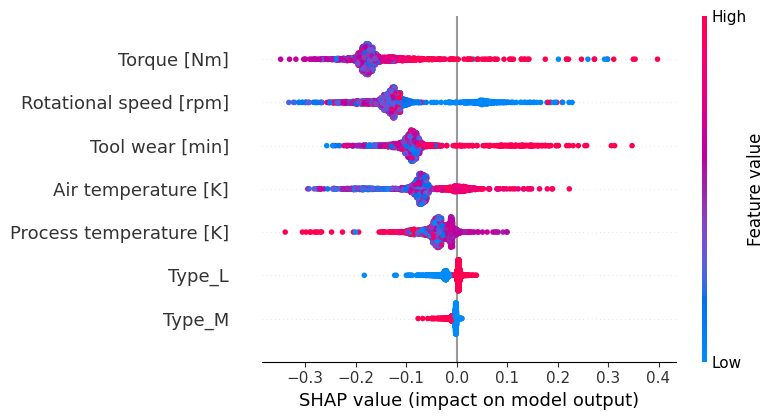

In [17]:
shap.summary_plot(shap_values[:, :, 1], X_test)